In [1]:
import sys
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate,SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
sys.path.insert(1, r'C:\Users\Dharmendra Vartika\LLM\env')
from enviorment import load_env
import os 
load_env()
model =ChatOpenAI()
from langgraph.graph import StateGraph,START, END
from typing import TypedDict,Annotated,Literal
import operator
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
import yfinance as yf
from ta.momentum import RSIIndicator
from pydantic import BaseModel, Field



In [ ]:
class model_output(BaseModel):
    """model output"""
    Trend_analysis: str = Field(description="The gives us the trend analysis of the stock")
    Support_Resistance: str = Field(description="The gives us the Support/Resistance levels of stock")
    Technical_rating : Literal["Bullish", "Neutral", "Bearish"]
    Key_signals :str  = Field(description="The gives us key signals stock by looking at the latest news")
    urls :str  = Field(description="The gives us urls for the refrence"),
    sentiments :Literal["positive", "negative", "neutral"]  = Field(description="The gives us sentiments for the refrence")
    Final_recommendation: Literal["Strong Buy", "Buy", "Hold","Sell",'Strong Sell'] = Field(description="The gives us the final recommendation of the stock")
    Confidence_score: int = Field(description="The gives Confidence score ranging from 0 to 10")
    Target_price_range : float =Field(description='Target price range of the stock')
    news: str = Field(description="recents news of the stock")
model_with_structured_output=model.with_structured_output(model_output)

In [ ]:
search_Tavily = TavilySearchResults(max_results=2)
search_Tavily.invoke('')

In [2]:
class symbol(BaseModel):
    ticker_symbol: str =Field(description='ticker symbol for the stock')
#search=DuckDuckGoSearchRun()
search_Tavily = TavilySearchResults(max_results=2)
tool=[search_Tavily]
#prompt ='can you get ticker symbol only for the Quantum-Si (QSI) stock'
llm_with_tools = model.bind_tools(tool)
llm_bind=llm_with_tools.with_structured_output(symbol)
tool_node = ToolNode(tool)
#result=llm_bind.invoke(prompt)
#result.ticker_symbol
class stock_analyzer(TypedDict):
    prompt :str
    symbol :str
    

C:\Users\Dharmendra Vartika\AppData\Local\Temp\ipykernel_18428\1926318328.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  search_Tavily = TavilySearchResults(max_results=2)
c:\Anaconda\Lib\site-packages\langchain_openai\chat_models\base.py:1913: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


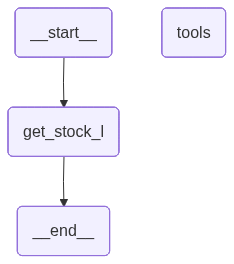

In [15]:
def get_stock(state:stock_analyzer):
    """Node for getting the ticker symbol"""
    prompt =state['prompt']
    #print ('prompt is ',prompt)
    result =llm_bind.invoke(prompt)
    #print ('output  is --->',result)
    stock=result.ticker_symbol
    state['symbol']=stock
    return state
graph=StateGraph(stock_analyzer)

graph.add_node('get_stock_l',get_stock)

graph.add_node('tools',tool_node)
##########################edge nodes############################
graph.add_edge(START,'get_stock_l')
#graph.add_conditional_edges('get_stock_l',tools_condition)
graph.add_edge('tools','get_stock_l')
graph.add_edge('get_stock_l',END)
workflow=graph.compile()
workflow


In [17]:
prompt='can you perform technial analysis for the Tesla stock and provide recommendation'
#prompt='can you get me latest price of Quantum-Si stock and tell me how much it cost me to buy 50 shares of it'
#initial_state={'symbol':symbol}
initial_state={'prompt':prompt}
#print (initial_state)
workflow.invoke(initial_state)

{'prompt': 'can you perform technial analysis for the Tesla stock and provide recommendation',
 'symbol': 'TSLA'}

In [5]:
def get_stock_test(prompt):
    """Node for getting the ticker symbol"""
    #prompt =state['prompt']
    print ('prompt is --->',prompt)
    result =llm_bind.invoke(prompt)
    print ('output  is --->',result)
    stock=result.ticker_symbol
    #state['symbol']=stock
    return stock
prompt='can you perform technial analysis for the Tesla stock and provide recommendation'
get_stock_test(prompt)

prompt is ---> can you perform technial analysis for the Tesla stock and provide recommendation
output  is ---> ticker_symbol='TSLA'


'TSLA'